## Obtain the Antenna S11 for B+18 pipeline

In [4]:
import hickle
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from astropy import units as un
from edges_analysis.calibration.s11 import AntennaS11
from edges_cal import modelling as mdl
from edges_cal.tools import FrequencyRange

In [6]:
repodir: str = "/data4/smurray/edges/projects_with_nive/edges-bowman2018-pipeline/"

In [7]:
repodir = Path(repodir)

In [17]:
plt.style.use("dark_background")

In [10]:
s11freq, s11real, s11imag = np.genfromtxt(
    repodir / "src/edges_pipelines/input-data/S11_blade_low_band_2015_342_03_14.txt.csv", skip_header=1, delimiter=","
).T

In [11]:
s11freq = FrequencyRange(s11freq * un.Hz, f_low=50 * un.MHz, f_high=100.0 * un.MHz)

In [12]:
ants11 = AntennaS11(
    raw_s11=(s11real + s11imag * 1j)[s11freq.mask],
    freq=s11freq,
    n_terms=10,
    complex_model_type=mdl.ComplexRealImagModel,
    model_type=mdl.Polynomial,
    model_transform=mdl.LogTransform(scale=1.0),
    set_transform_range=True,
    fit_kwargs={"method": "alan-qrd"},
    internal_switch=None,
).with_model_delay()

In [13]:
ants11.model_delay

<Quantity 0.0268 us>

In [14]:
alan = np.genfromtxt(
    "/home/smurray/data4/edges/alans-pipeline/scripts/H2CaseFieldData/627/modeled_antenna_s11.txt"
)

In [15]:
mymod = ants11.s11_model(alan[:, 0] * un.MHz)

In [18]:
alans11 = alan[:, 1] + 1j*alan[:, 2]

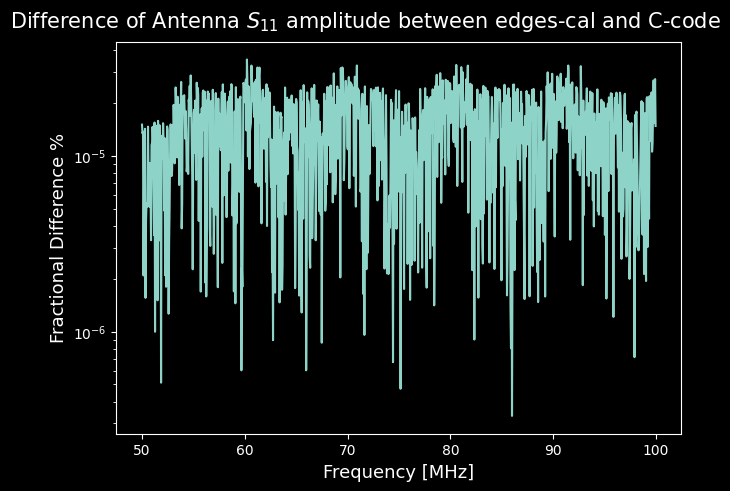

In [32]:
fig, ax = plt.subplots(1, 1, sharex=True, constrained_layout=True, gridspec_kw={'hspace': 0})

ax.plot(alan[:, 0], 100*np.abs(alans11 - mymod)/np.abs(mymod))
ax.set_yscale('log')

# ax[1].plot(alan[:, 0], np.unwrap(np.angle(alans11-mymod)))
# ax[1].set_ylabel("Phase Difference [rad]")
#plt.plot(alan[:, 0], alan[:, 2] - mymod.imag)
ax.set_xlabel("Frequency [MHz]", fontsize=13)
ax.set_ylabel("Fractional Difference %", fontsize=13)
fig.suptitle("Difference of Antenna $S_{11}$ amplitude between edges-cal and C-code", fontsize=15);

In [55]:
hickle.dump(ants11, "../outputs/2015_ants11_modelled_redone.h5")

/data4/smurray/edges/.venv/lib/python3.11/site-packages/hickle/lookup.py:1491: SerializedWarning: 'slice' type not understood, data is serialized:
  warnings.warn(
/data4/smurray/edges/.venv/lib/python3.11/site-packages/hickle/lookup.py:1491: SerializedWarning: 'ABCMeta' type not understood, data is serialized:
  warnings.warn(
/data4/smurray/edges/.venv/lib/python3.11/site-packages/hickle/lookup.py:1491: SerializedWarning: 'YAMLObjectMetaclass' type not understood, data is serialized:
  warnings.warn(
